In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns


**LOAD & PREPROCESS DATA**

In [2]:
from google.colab import files
uploaded = files.upload()


Saving combined_final_with_lags.csv to combined_final_with_lags.csv


In [3]:
df = pd.read_csv("combined_final_with_lags.csv")

df = df.sort_values(
    by=["City_encoded", "Year", "Month"]
).reset_index(drop=True)


**Noise buckets (classification targets)**

In [4]:
def day_risk(x):
    if x < 55: return 0
    elif x < 65: return 1
    else: return 2

def night_risk(x):
    if x < 45: return 0
    elif x < 55: return 1
    else: return 2

df["Day_risk"] = df["Day"].apply(day_risk)
df["Night_risk"] = df["Night"].apply(night_risk)


**Cyclical encoding**

In [5]:
df["month_sin"] = np.sin(2*np.pi*df["Month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["Month"]/12)


In [6]:
df = df.sort_values(
    by=["City_encoded", "Year", "Month"]
).reset_index(drop=True)

# AQI rolling features (PAST ONLY)
df["AQI_roll3_past"] = (
    df.groupby("City_encoded")["avg_AQI"]
      .shift(1)
      .rolling(3)
      .mean()
)

df["AQI_roll6_past"] = (
    df.groupby("City_encoded")["avg_AQI"]
      .shift(1)
      .rolling(6)
      .mean()
)

# Noise rolling features (PAST ONLY)
df["Day_roll3_past"] = (
    df.groupby("City_encoded")["Day"]
      .shift(1)
      .rolling(3)
      .mean()
)

df["Night_roll3_past"] = (
    df.groupby("City_encoded")["Night"]
      .shift(1)
      .rolling(3)
      .mean()
)

# Drop rows created by rolling
df = df.dropna().reset_index(drop=True)


**Feature list**

In [7]:
FEATURES = [
    "avg_AQI_lag1","avg_AQI_lag2","avg_AQI_lag3",
    "AQI_roll3_past","AQI_roll6_past",
    "Day_lag1","Day_lag2","Day_roll3_past",
    "Night_lag1","Night_lag2","Night_roll3_past",
    "month_sin","month_cos"
]


**SEQUENCE GENERATION**

In [8]:
def build_sequences(df, window=6):
    X, y_aqi, y_day, y_night = [], [], [], []

    for city in df["City_encoded"].unique():
        cdf = df[df["City_encoded"] == city]
        vals = cdf[FEATURES + ["avg_AQI","Day_risk","Night_risk"]].values
        f = len(FEATURES)

        for i in range(window, len(vals)):
            X.append(vals[i-window:i,:f])
            y_aqi.append(vals[i,f])
            y_day.append(vals[i,f+1])
            y_night.append(vals[i,f+2])

    return np.array(X), np.array(y_aqi), np.array(y_day), np.array(y_night)


In [9]:
X, y_aqi, y_day, y_night = build_sequences(df)


**TRAIN-TEST SPLIT & SCALING**

In [10]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_aqi_train, y_aqi_test = y_aqi[:split], y_aqi[split:]
y_day_train, y_day_test = y_day[:split], y_day[split:]
y_night_train, y_night_test = y_night[:split], y_night[split:]


In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
n_feat = X_train.shape[2]

X_train = scaler.fit_transform(
    X_train.reshape(-1,n_feat)
).reshape(X_train.shape)

X_test = scaler.transform(
    X_test.reshape(-1,n_feat)
).reshape(X_test.shape)


**TRANSFORMER ARCHITECTURES**

In [12]:
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, Conv1D, Flatten
)
from tensorflow.keras.models import Model
import tensorflow as tf


**Vanilla Time-Series Transformer**

In [13]:
def vanilla_transformer(x, heads, key_dim, ff_dim, dropout, activation):
    mha = MultiHeadAttention(num_heads=heads, key_dim=key_dim)

    attn_output = mha(x, x)  # normal training path
    x = LayerNormalization()(x + attn_output)

    ff = Dense(ff_dim, activation=activation)(x)
    ff = Dense(x.shape[-1])(ff)

    return LayerNormalization()(x + ff)


**Hybrid Conv + Attention Transformer**

In [14]:
def conv_attn_transformer(x, heads, key_dim, ff_dim, dropout, activation):
    x = Conv1D(32, 3, padding="same", activation=activation)(x)

    mha = MultiHeadAttention(
        num_heads=heads,
        key_dim=key_dim
    )

    attn_output = mha(x, x)
    x = LayerNormalization()(x + attn_output)

    ff = Dense(ff_dim, activation=activation)(x)
    ff = Dense(x.shape[-1])(ff)

    return LayerNormalization()(x + ff)


**Simplified Temporal Fusion Transformer (TFT-Inspired)**

In [15]:
def tft_block(x, heads, key_dim, ff_dim, dropout, activation):
    mha = MultiHeadAttention(
        num_heads=heads,
        key_dim=key_dim
    )

    attn_output = mha(x, x)
    x = LayerNormalization()(x + attn_output)

    gated = Dense(ff_dim, activation=activation)(x)
    gated = Dense(x.shape[-1], activation="sigmoid")(gated)

    return LayerNormalization()(x + gated)


**MODEL BUILDER (MULTI-TASK)**

In [16]:
def build_model(block_fn, block_cfg, train_cfg):
    inp = Input(shape=X_train.shape[1:])

    x = block_fn(inp, **block_cfg)
    x = Dropout(block_cfg["dropout"])(x)
    x = Flatten()(x)

    shared = Dense(128, activation=block_cfg["activation"])(x)

    # AQI regression head
    aqi_out = Dense(1, name="aqi")(shared)

    # Noise classification heads
    noise_hidden = Dense(64, activation=block_cfg["activation"])(shared)
    day_out = Dense(3, activation="softmax", name="day")(noise_hidden)
    night_out = Dense(3, activation="softmax", name="night")(noise_hidden)

    model = Model(inp, [aqi_out, day_out, night_out])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(train_cfg["lr"]),
        loss={
            "aqi": "mse",
            "day": "sparse_categorical_crossentropy",
            "night": "sparse_categorical_crossentropy",
        },
        loss_weights={"aqi": 1.0, "day": 0.6, "night": 0.6},
    )

    return model


**TRAIN + EVALUATE FUNCTION (CORE)**

In [17]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_squared_log_error, r2_score,
    explained_variance_score, max_error,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, matthews_corrcoef,
    cohen_kappa_score, log_loss,
    roc_auc_score, average_precision_score,
    brier_score_loss
)
import numpy as np


**Regression metrics (AQI)**

In [18]:
def regression_metrics(y_true, y_pred, n_features):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    rmsle = np.sqrt(mean_squared_log_error(
        np.maximum(y_true, 0),
        np.maximum(y_pred, 0)
    ))

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

    evs = explained_variance_score(y_true, y_pred)
    max_err = max_error(y_true, y_pred)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "RMSLE": rmsle,
        "MAPE": mape,
        "SMAPE": smape,
        "R2": r2,
        "Adj_R2": adj_r2,
        "Explained_Var": evs,
        "Max_Error": max_err,
    }


**Classification metrics (Noise)**

In [19]:
def classification_metrics(y_true, y_prob):
    # 🔑 Force integer labels
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)

    y_pred = np.argmax(y_prob, axis=1)

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),

        "Precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Precision_micro": precision_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "Precision_weighted": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),

        "Recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Recall_micro": recall_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "Recall_weighted": recall_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),

        "F1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "F1_micro": f1_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "F1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),

        "MCC": matthews_corrcoef(y_true, y_pred),
        "Cohen_Kappa": cohen_kappa_score(y_true, y_pred),

        "Log_Loss": log_loss(y_true, y_prob),

        # Multi-class One-vs-Rest
        "AUC_ROC": roc_auc_score(
            y_true, y_prob, multi_class="ovr"
        ),

        "AUC_PR": average_precision_score(
            np.eye(3)[y_true],
            y_prob,
            average="macro"
        ),

        "Brier": np.mean([
            brier_score_loss(
                (y_true == i).astype(int),
                y_prob[:, i]
            )
            for i in range(3)
        ])
    }

    return metrics


**Experiments**

In [20]:
experiments = {
    "Vanilla-Transformer": {
        "block_fn": vanilla_transformer,
        "block_cfg": {
            "heads": 4,
            "key_dim": 32,
            "ff_dim": 128,
            "dropout": 0.2,
            "activation": "gelu"
        },
        "train_cfg": {
            "lr": 5e-4
        }
    },
    "Conv-Attn-Transformer": {
        "block_fn": conv_attn_transformer,
        "block_cfg": {
            "heads": 4,
            "key_dim": 32,
            "ff_dim": 128,
            "dropout": 0.3,
            "activation": "gelu"
        },
        "train_cfg": {
            "lr": 5e-4
        }
    },
    "TFT-Simplified": {
        "block_fn": tft_block,
        "block_cfg": {
            "heads": 4,
            "key_dim": 32,
            "ff_dim": 128,
            "dropout": 0.3,
            "activation": "gelu"
        },
        "train_cfg": {
            "lr": 3e-4
        }
    }
}


**TRAIN + COLLECT RESULTS**

In [21]:
def train_and_eval(name, block_fn, block_cfg, train_cfg):
    model = build_model(block_fn, block_cfg, train_cfg)

    history = model.fit(
        X_train,
        {"aqi": y_aqi_train, "day": y_day_train, "night": y_night_train},
        epochs=80,
        batch_size=32,
        validation_split=0.1,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            patience=12, restore_best_weights=True
        )],
        verbose=0
    )

    aqi_p, day_p, night_p = model.predict(X_test, verbose=0)

    reg = regression_metrics(y_aqi_test, aqi_p, X_test.shape[2])
    clf_day = classification_metrics(y_day_test, day_p)
    clf_night = classification_metrics(y_night_test, night_p)

    return model, history, reg, clf_day, clf_night


In [22]:
results = {}
trained_models = {}
training_histories = {}

for name, cfg in experiments.items():
    print(f"Training {name}...")

    model, history, reg_metrics, day_metrics, night_metrics = train_and_eval(
        name,
        cfg["block_fn"],
        cfg["block_cfg"],
        cfg["train_cfg"]
    )

    results[name] = {
        "reg": reg_metrics,
        "day": day_metrics,
        "night": night_metrics
    }

    trained_models[name] = model
    training_histories[name] = history


Training Vanilla-Transformer...
Training Conv-Attn-Transformer...
Training TFT-Simplified...


**RESULTS TABLE (IEEE-READY)**

In [23]:
import pandas as pd

summary_rows = []

for name, metrics in results.items():
    reg = metrics["reg"]
    day = metrics["day"]
    night = metrics["night"]

    row = {"Model": name}
    row.update({f"AQI_{k}": v for k, v in reg.items()})
    row.update({f"Day_{k}": v for k, v in day.items()})
    row.update({f"Night_{k}": v for k, v in night.items()})

    summary_rows.append(row)

results_df = pd.DataFrame(summary_rows)
results_df
results_df.to_csv("transformer_model_full_metrics.csv", index=False)
from google.colab import files
files.download("transformer_model_full_metrics.csv")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**AQI: Scatter, Residuals, Histogram, Q-Q**

In [24]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np


In [25]:
vanilla_model = trained_models["Vanilla-Transformer"]

aqi_pred_vanilla, _, _ = vanilla_model.predict(X_test, verbose=0)


In [26]:
def plot_aqi_diagnostics(y_true, y_pred, title):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    residuals = y_true - y_pred

    fig = plt.figure(figsize=(15,4))

    # 1️⃣ Predicted vs Actual
    ax1 = fig.add_subplot(1,3,1)
    ax1.scatter(y_true, y_pred, alpha=0.4)
    ax1.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        "--", color="red"
    )
    ax1.set_title("Predicted vs Actual")
    ax1.set_xlabel("Actual AQI")
    ax1.set_ylabel("Predicted AQI")

    # 2️⃣ Residual Histogram
    ax2 = fig.add_subplot(1,3,2)
    ax2.hist(residuals, bins=30)
    ax2.set_title("Residual Distribution")
    ax2.set_xlabel("Residual")
    ax2.set_ylabel("Frequency")

    # 3️⃣ Q-Q Plot
    ax3 = fig.add_subplot(1,3,3)
    stats.probplot(residuals, plot=ax3)
    ax3.set_title("Q-Q Plot")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


Generating AQI diagnostics for Vanilla-Transformer...


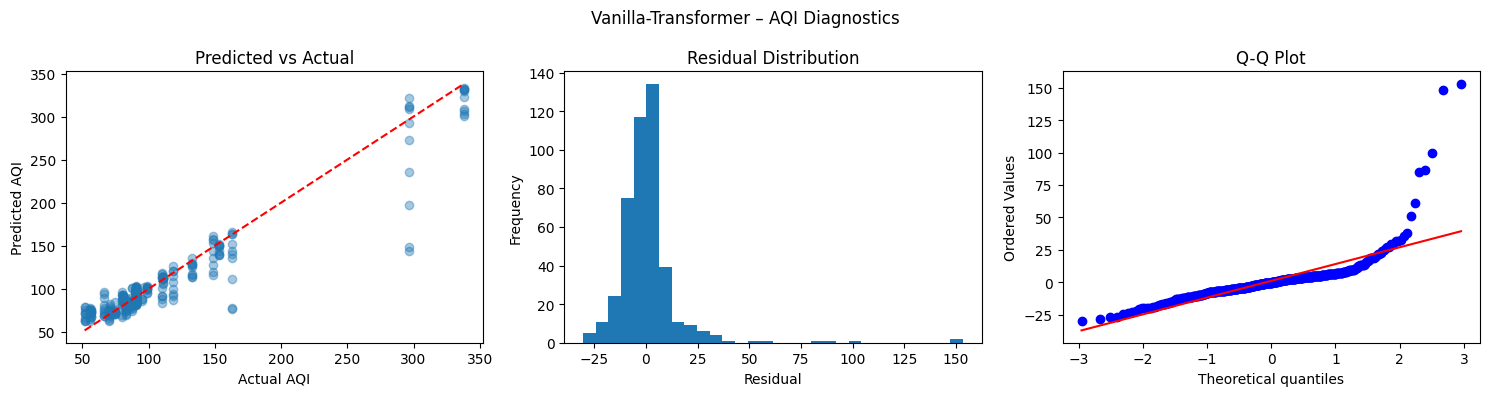

Generating AQI diagnostics for Conv-Attn-Transformer...


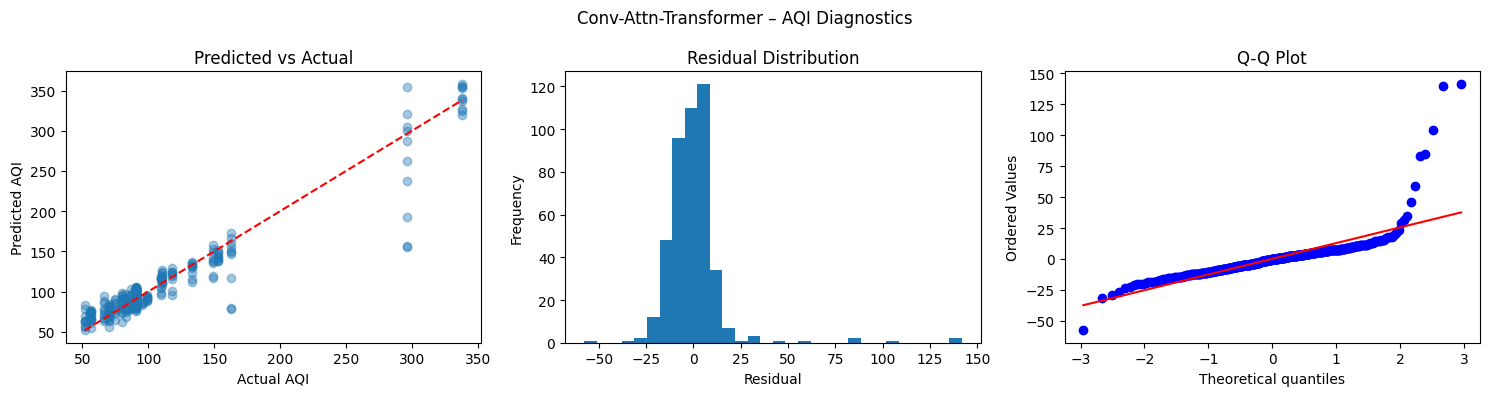

Generating AQI diagnostics for TFT-Simplified...


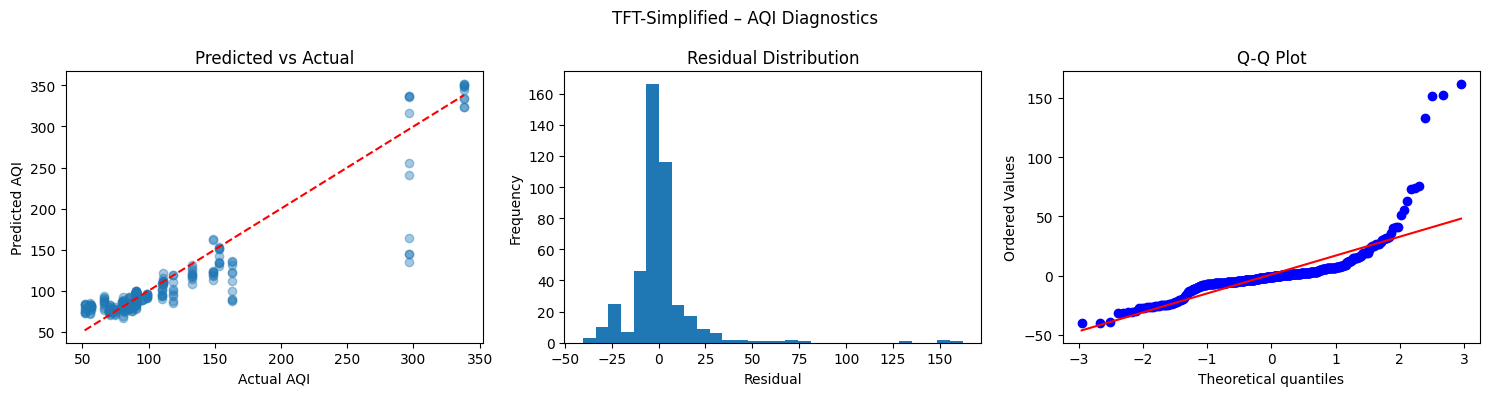

In [27]:
for model_name, model in trained_models.items():
    print(f"Generating AQI diagnostics for {model_name}...")

    # Get predictions
    aqi_pred, _, _ = model.predict(X_test, verbose=0)

    # Plot diagnostics
    plot_aqi_diagnostics(
        y_aqi_test,
        aqi_pred,
        f"{model_name} – AQI Diagnostics"
    )


In [28]:
plt.savefig(f"{model_name}_AQI_diagnostics.png", dpi=300, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve
)
from sklearn.preprocessing import label_binarize


**Scatter Plot (Predicted vs Actual)**

In [30]:
def plot_scatter(y_true, y_pred, title):
    plt.scatter(y_true, y_pred, alpha=0.4)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()], '--')
    plt.xlabel("Actual AQI")
    plt.ylabel("Predicted AQI")
    plt.title(title)
    plt.show()


**Time-Series Line Plot**

In [31]:
def plot_timeseries(y_true, y_pred, title, n=200):
    plt.plot(y_true[:n], label="Actual")
    plt.plot(y_pred[:n], label="Predicted")
    plt.legend()
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("AQI")
    plt.show()


**Residual Plot**

In [32]:
def plot_residuals(y_pred, residuals, title):
    plt.scatter(y_pred, residuals, alpha=0.4)
    plt.axhline(0)
    plt.xlabel("Predicted AQI")
    plt.ylabel("Residual")
    plt.title(title)
    plt.show()


**Histogram of Errors**

In [33]:
def plot_residual_hist(residuals, title):
    plt.hist(residuals, bins=30)
    plt.title(title)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.show()


**Q–Q Plot**

In [34]:
def plot_qq(residuals, title):
    stats.probplot(residuals, plot=plt)
    plt.title(title)
    plt.show()


**Box Plot (Error Distribution)**

In [35]:
def plot_error_box(residuals, title):
    sns.boxplot(residuals)
    plt.title(title)
    plt.show()


**Generate ALL AQI plots for ALL models**

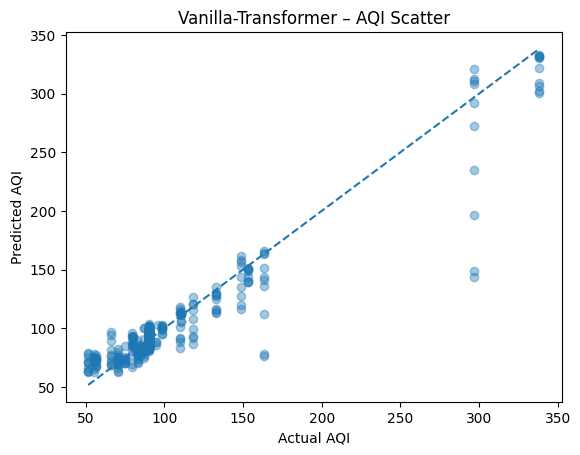

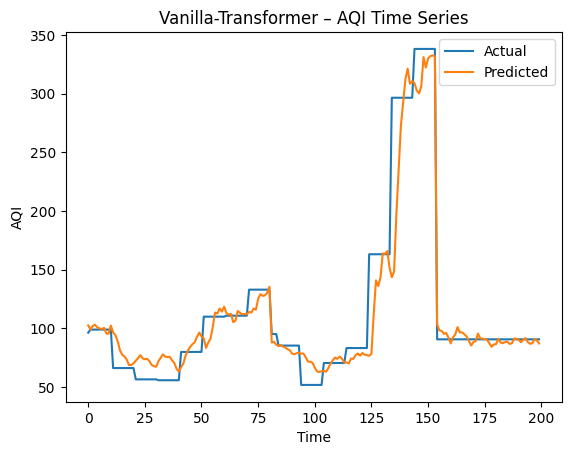

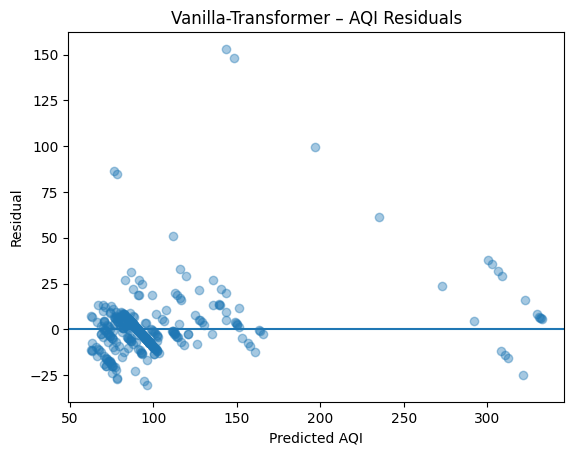

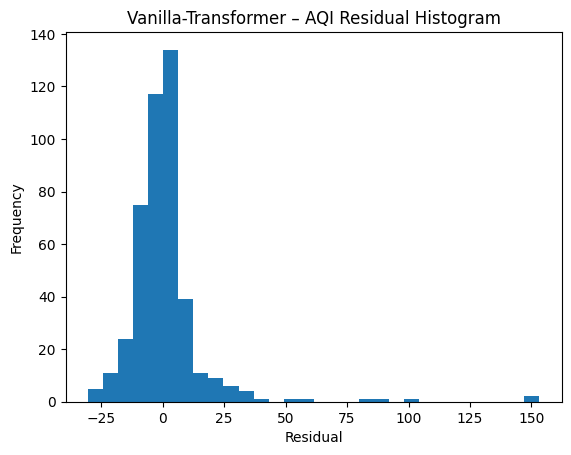

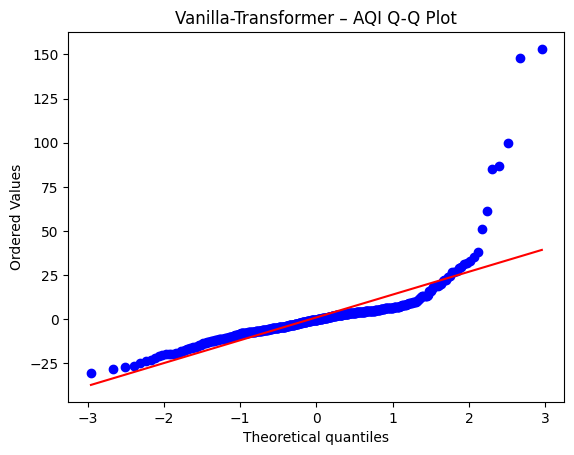

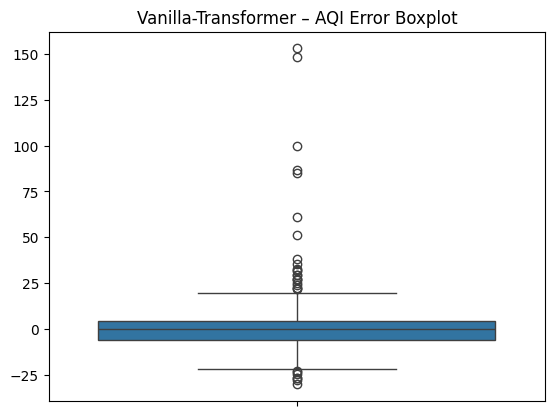

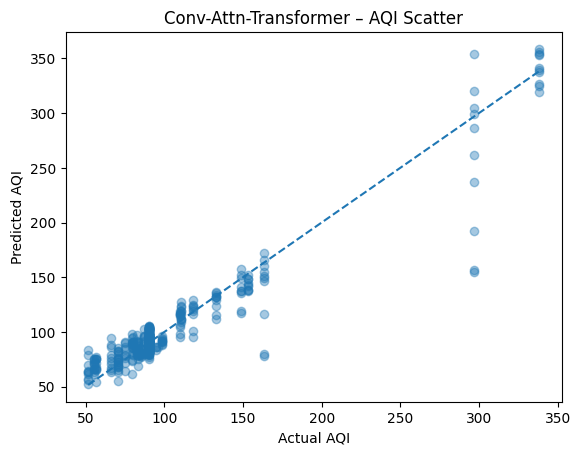

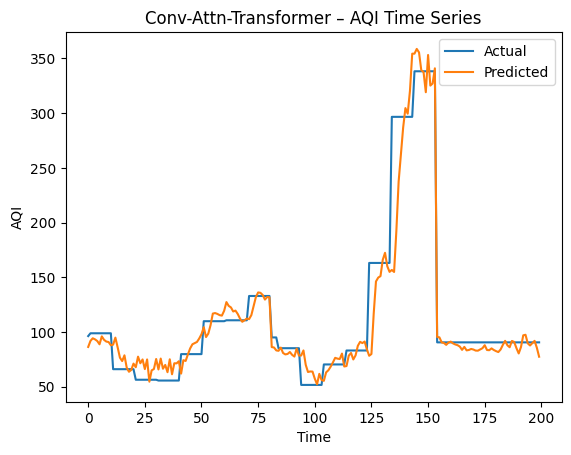

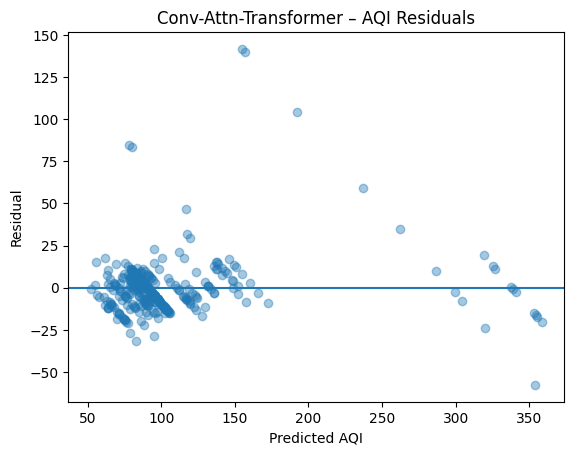

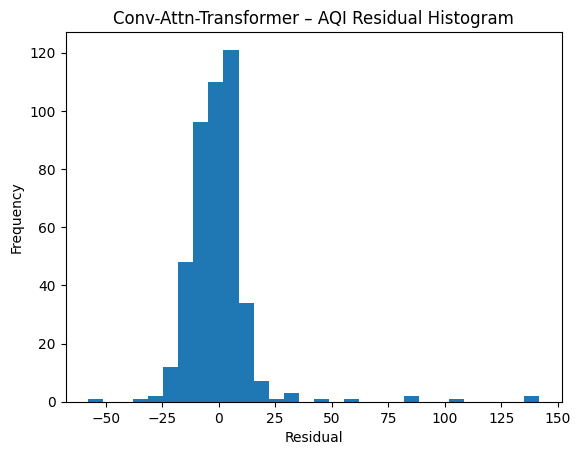

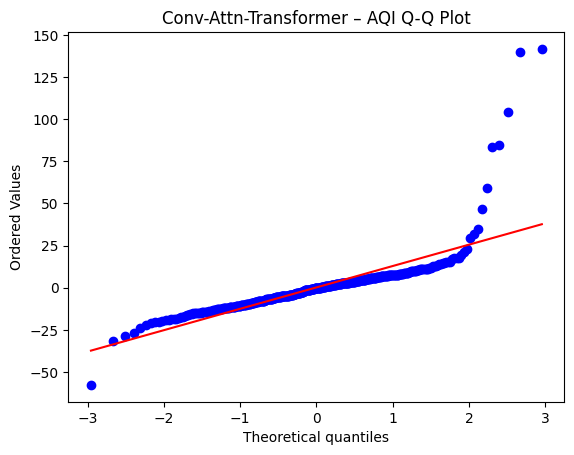

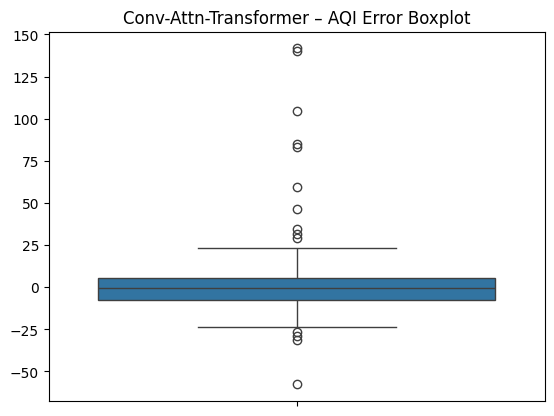

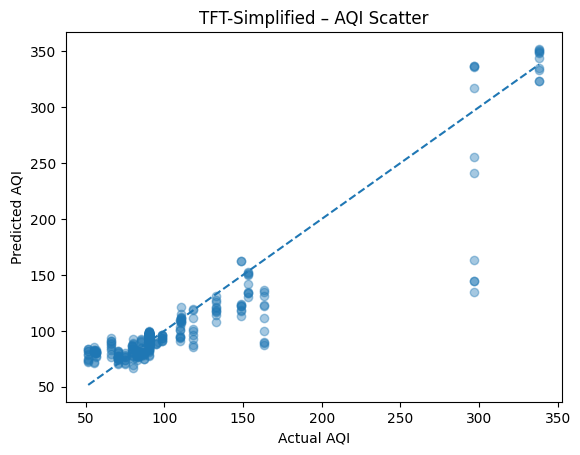

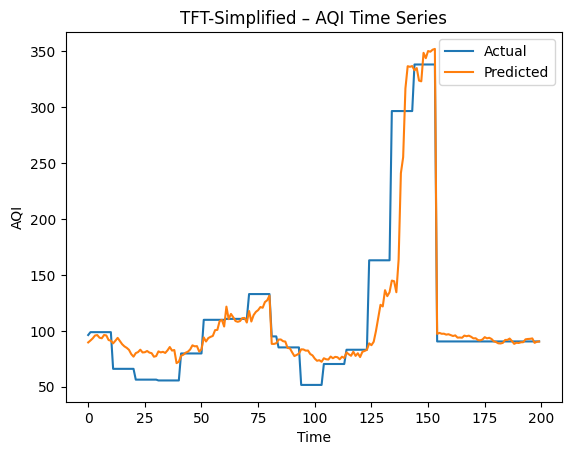

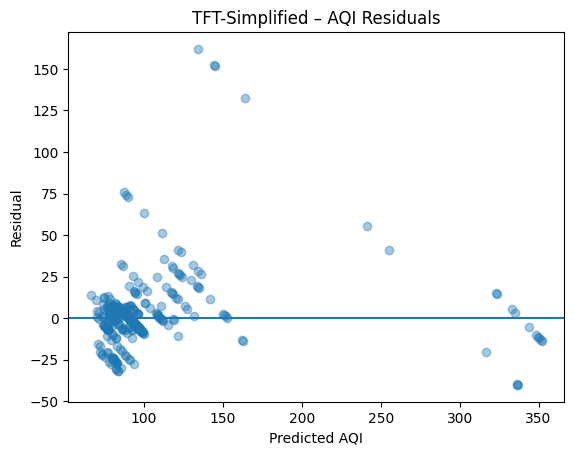

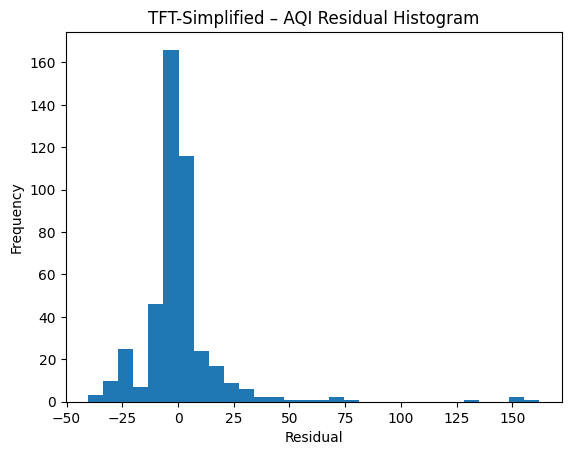

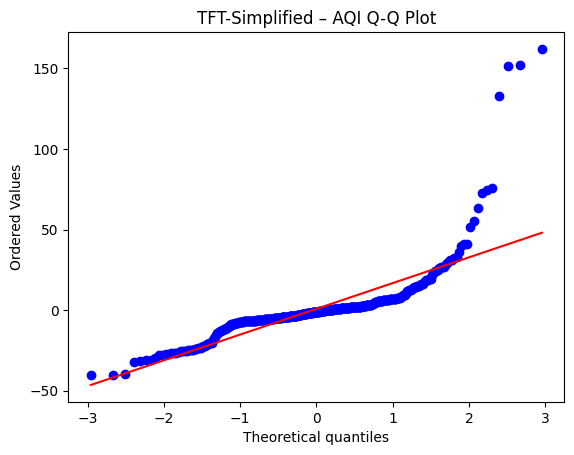

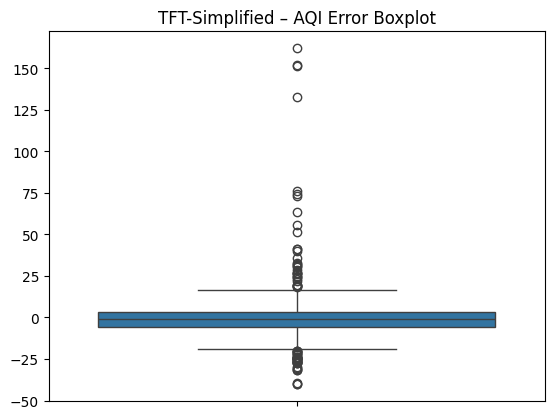

In [36]:
for name, model in trained_models.items():
    aqi_pred, _, _ = model.predict(X_test, verbose=0)
    residuals = y_aqi_test - aqi_pred.flatten()

    plot_scatter(y_aqi_test, aqi_pred, f"{name} – AQI Scatter")
    plot_timeseries(y_aqi_test, aqi_pred.flatten(), f"{name} – AQI Time Series")
    plot_residuals(aqi_pred, residuals, f"{name} – AQI Residuals")
    plot_residual_hist(residuals, f"{name} – AQI Residual Histogram")
    plot_qq(residuals, f"{name} – AQI Q-Q Plot")
    plot_error_box(residuals, f"{name} – AQI Error Boxplot")


**NOISE (CLASSIFICATION)**

**Confusion Matrix**

In [37]:
def plot_confusion(y_true, y_prob, title):
    y_pred = np.argmax(y_prob, axis=1)
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["Low","Medium","High"],
                yticklabels=["Low","Medium","High"],
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()


**ROC Curve (OvR)**

In [38]:
def plot_roc(y_true, y_prob, title):
    y_bin = label_binarize(y_true, classes=[0,1,2])

    for i, lbl in enumerate(["Low","Medium","High"]):
        fpr, tpr, _ = roc_curve(y_bin[:,i], y_prob[:,i])
        plt.plot(fpr, tpr, label=lbl)

    plt.plot([0,1],[0,1],'k--')
    plt.legend()
    plt.title(title)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.show()


**Precision–Recall Curve**

In [39]:
def plot_pr(y_true, y_prob, title):
    y_bin = label_binarize(y_true, classes=[0,1,2])

    for i, lbl in enumerate(["Low","Medium","High"]):
        p, r, _ = precision_recall_curve(y_bin[:,i], y_prob[:,i])
        plt.plot(r, p, label=lbl)

    plt.legend()
    plt.title(title)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()


**Calibration Curve**

In [40]:
from sklearn.calibration import calibration_curve

def plot_calibration(y_true, y_prob, title):
    y_pred = np.argmax(y_prob, axis=1)

    frac_pos, mean_pred = calibration_curve(
        (y_true == 2).astype(int),
        y_prob[:,2],
        n_bins=10
    )

    plt.plot(mean_pred, frac_pos, marker='o')
    plt.plot([0,1],[0,1],'--')
    plt.title(title)
    plt.xlabel("Predicted Probability")
    plt.ylabel("True Frequency")
    plt.show()


**Generate ALL noise plots for ALL models**

Noise plots for Vanilla-Transformer


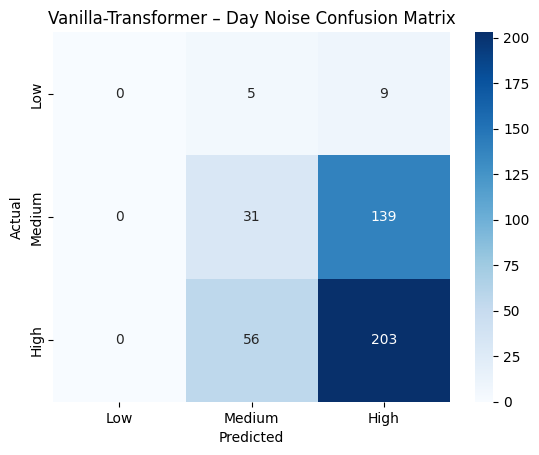

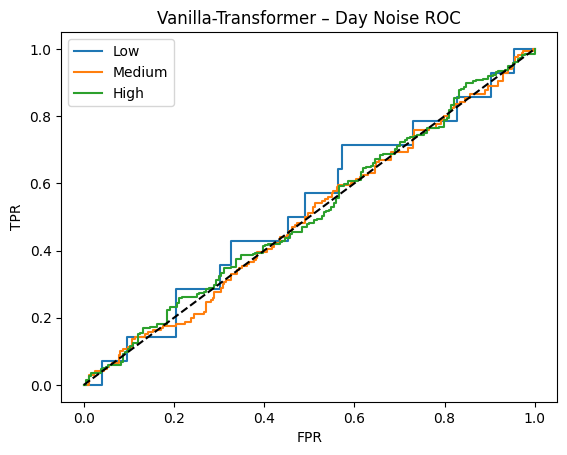

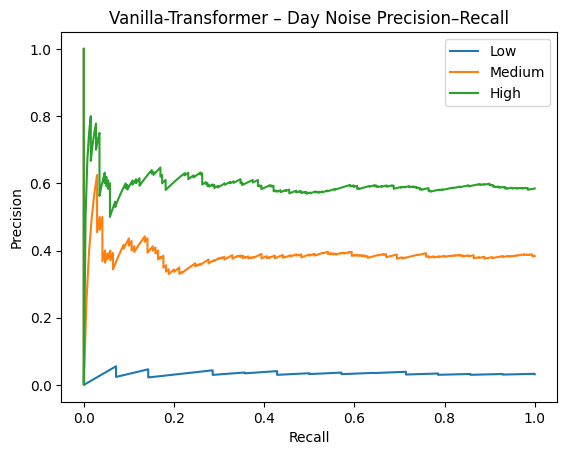

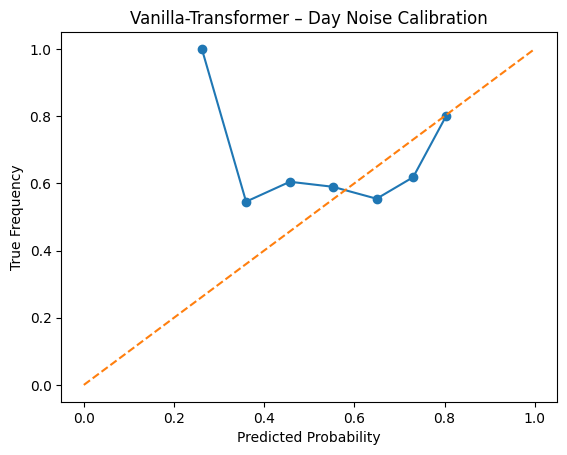

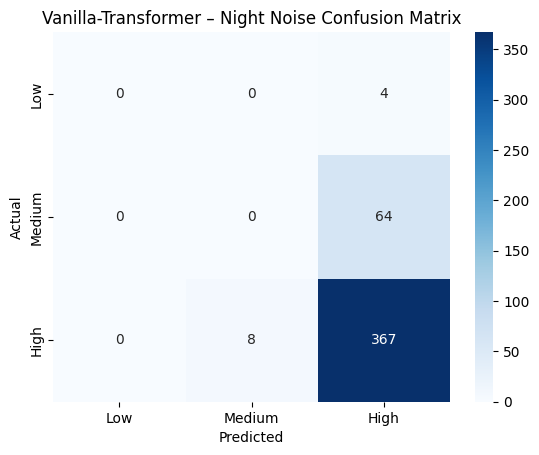

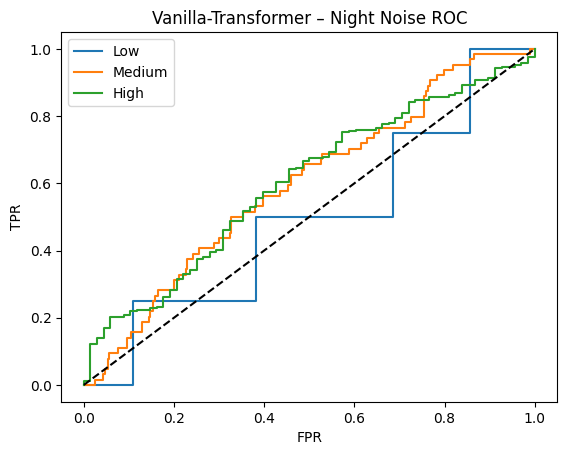

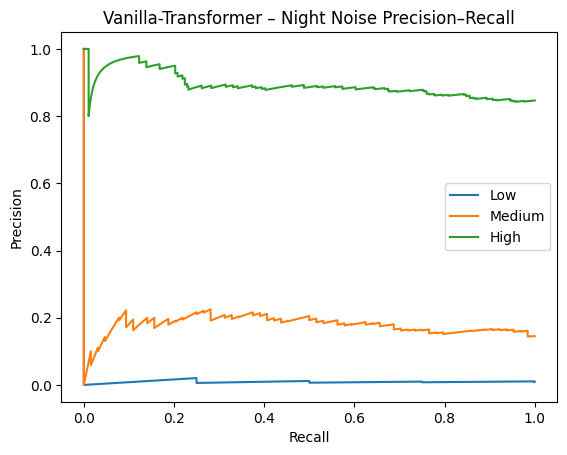

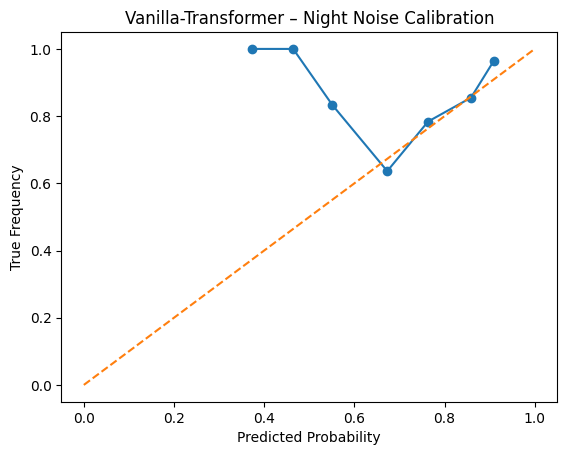

Noise plots for Conv-Attn-Transformer


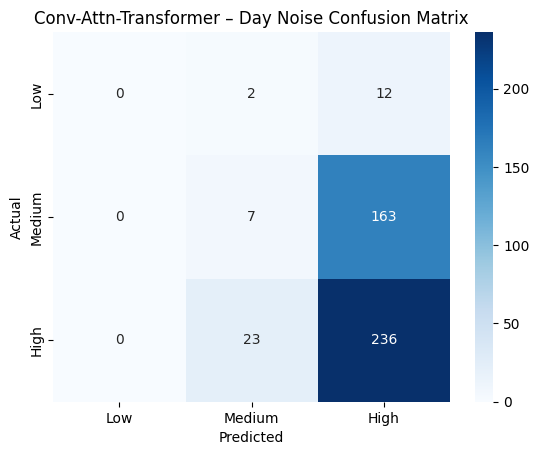

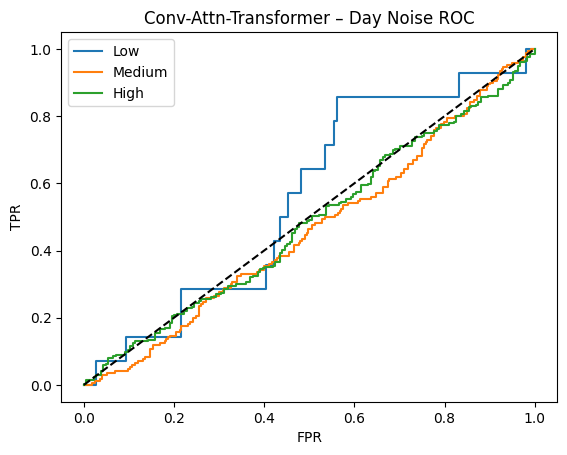

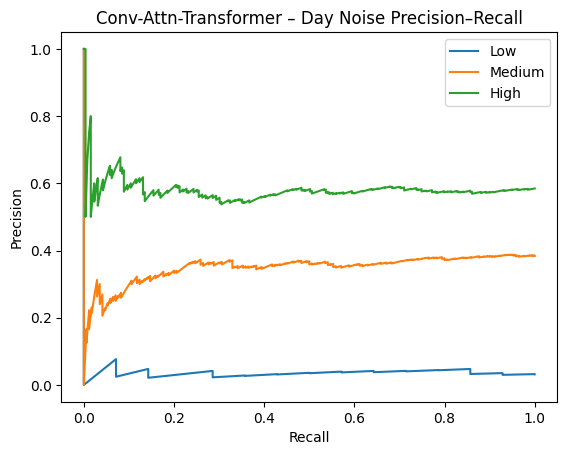

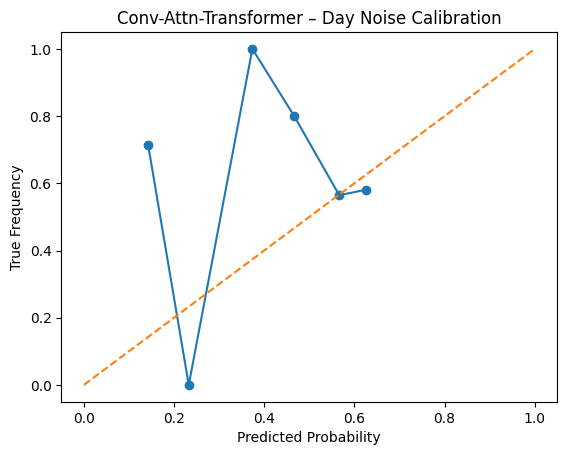

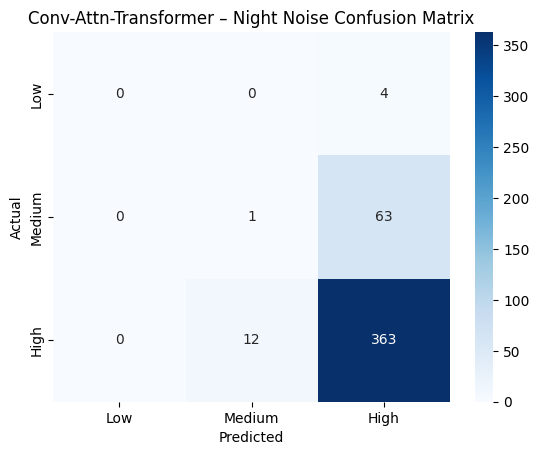

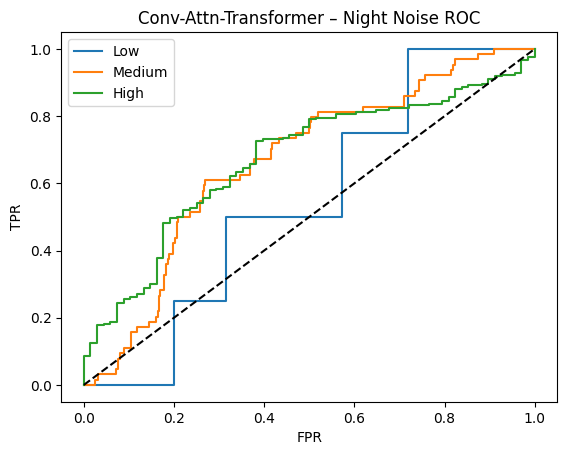

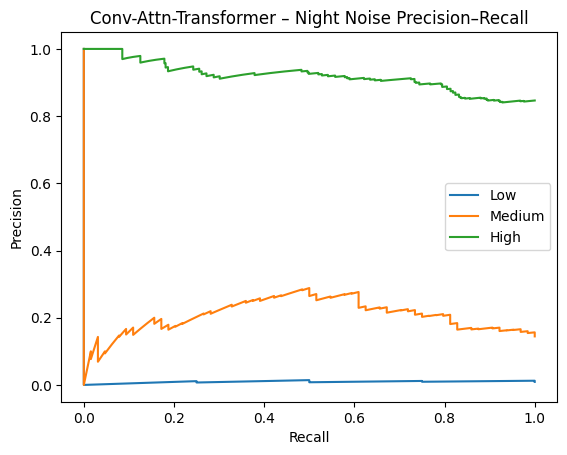

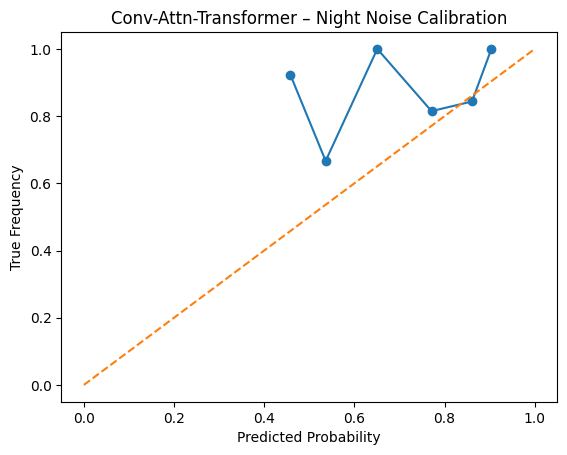

Noise plots for TFT-Simplified


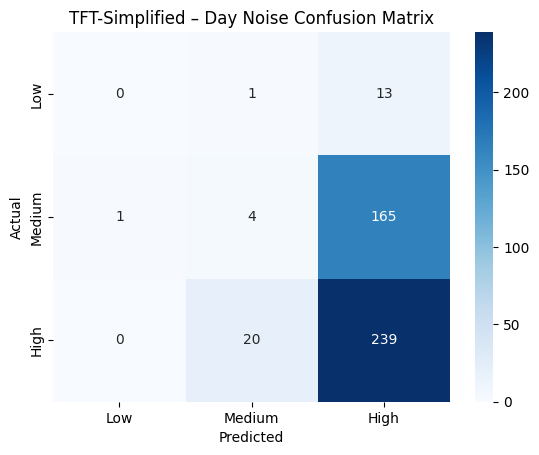

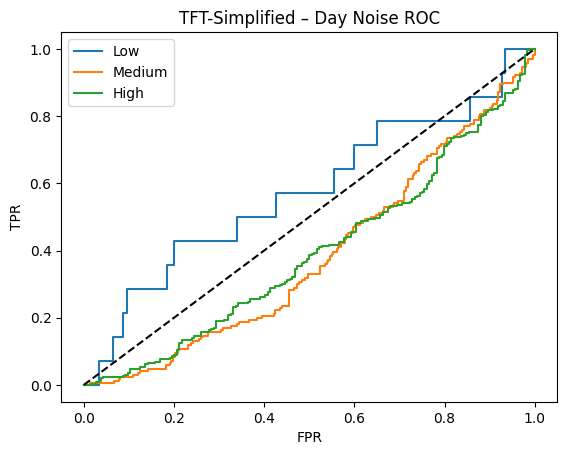

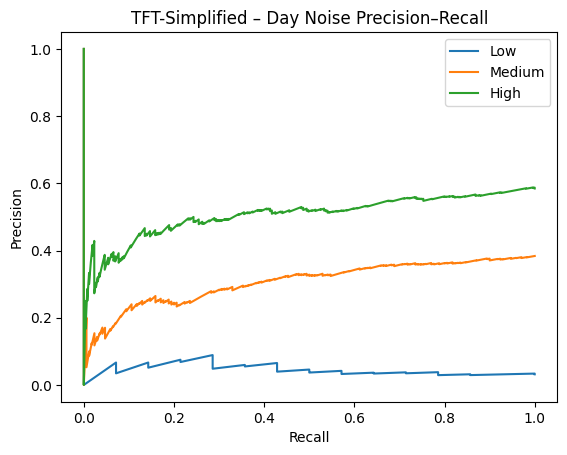

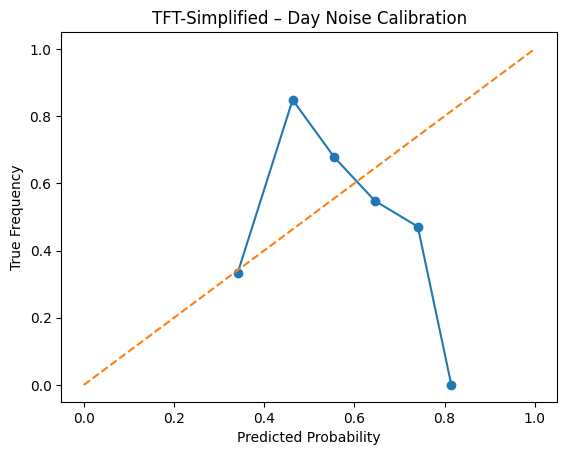

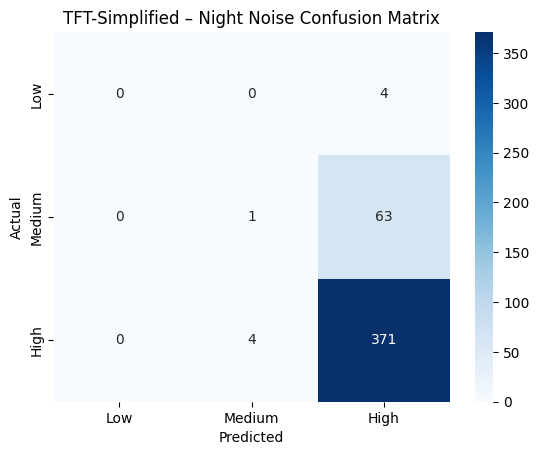

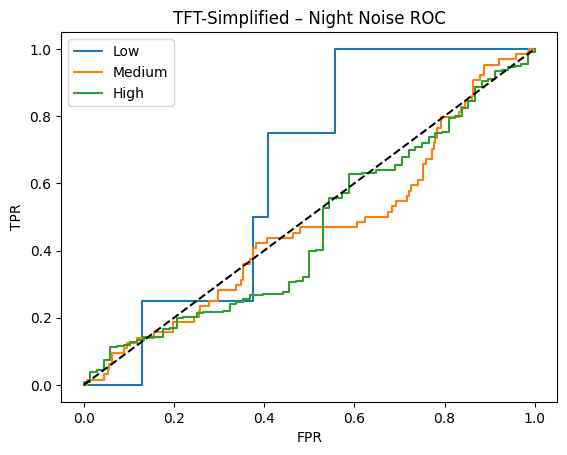

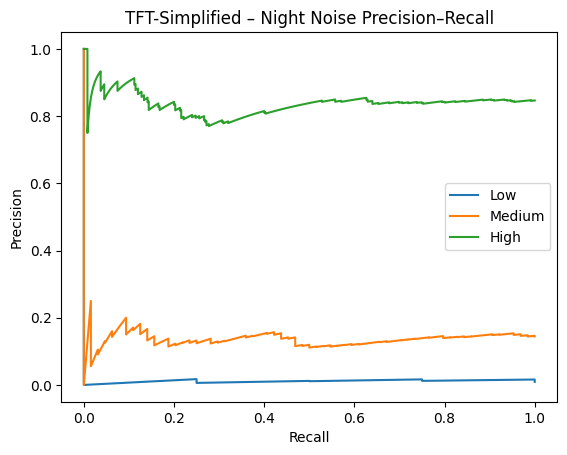

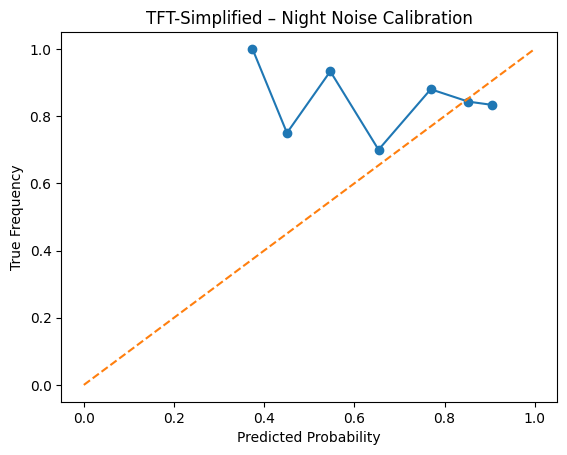

In [41]:
for name, model in trained_models.items():
    print(f"Noise plots for {name}")

    _, day_p, night_p = model.predict(X_test, verbose=0)

    # ===== DAY NOISE =====
    plot_confusion(
        y_day_test,
        day_p,
        f"{name} – Day Noise Confusion Matrix"
    )

    plot_roc(
        y_day_test,
        day_p,
        f"{name} – Day Noise ROC"
    )

    plot_pr(
        y_day_test,
        day_p,
        f"{name} – Day Noise Precision–Recall"
    )

    plot_calibration(
        y_day_test,
        day_p,
        f"{name} – Day Noise Calibration"
    )

    # ===== NIGHT NOISE =====
    plot_confusion(
        y_night_test,
        night_p,
        f"{name} – Night Noise Confusion Matrix"
    )

    plot_roc(
        y_night_test,
        night_p,
        f"{name} – Night Noise ROC"
    )

    plot_pr(
        y_night_test,
        night_p,
        f"{name} – Night Noise Precision–Recall"
    )

    plot_calibration(
        y_night_test,
        night_p,
        f"{name} – Night Noise Calibration"
    )


**install an import SHAP**

In [42]:
!pip install shap


In [43]:
import shap


**Create a wrapper for AQI prediction**

In [44]:
vanilla_model = trained_models["Vanilla-Transformer"]

def aqi_predict_fn(X):
    aqi_pred, _, _ = vanilla_model.predict(X, verbose=0)
    return aqi_pred


**Prepare background + test samples**

In [45]:
background = X_train[np.random.choice(len(X_train), 100, replace=False)]
test_sample = X_test[:200]


**Create an AQI-only model from your trained transformer**

In [46]:
import tensorflow as tf

# Extract AQI output only
aqi_only_model = tf.keras.Model(
    inputs=vanilla_model.input,
    outputs=vanilla_model.get_layer("aqi").output
)


In [47]:
explainer = shap.GradientExplainer(
    aqi_only_model,
    background
)


In [48]:
shap_values = explainer.shap_values(test_sample)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 6, 13))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 6, 13))']
  warnings.warn(msg)


**Aggregate time dimension**

In [49]:
shap_vals_agg = shap_values.mean(axis=1)
X_agg = test_sample.mean(axis=1)


**SHAP Summary Plot**

/tmp/ipython-input-419025529.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


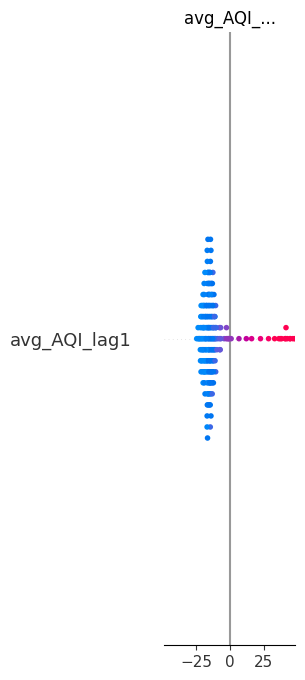

In [50]:
shap.summary_plot(
    shap_vals_agg,
    X_agg,
    feature_names=FEATURES,
    show=True
)


**Generic attention probe builder**

In [51]:
import tensorflow as tf
from tensorflow.keras.layers import MultiHeadAttention

def build_attention_probe_from_graph(model):
    mha_layer = None

    for layer in model.layers:
        if isinstance(layer, MultiHeadAttention):
            mha_layer = layer
            break

    if mha_layer is None:
        raise ValueError("No MultiHeadAttention layer found")

    # IMPORTANT: use the SAME tensor that was input to attention during training
    mha_input = mha_layer.input[0]  # <- this is Conv1D output for Conv-Attn

    # Re-run attention WITH scores
    _, attn_scores = mha_layer(
        mha_input, mha_input, return_attention_scores=True
    )

    return tf.keras.Model(
        inputs=model.input,
        outputs=attn_scores
    )


**Build probes for all three models**

**Conv-attn-Transformer**

In [52]:
attention_probes = {}

for name, model in trained_models.items():
    attention_probes[name] = build_attention_probe_from_graph(model)


**Generate heatmaps safely for ALL models**

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_attention_heatmap(attn_scores, name):
    """
    attn_scores: numpy array or tensor
                  expected shape:
                  (batch, heads, time, time) OR
                  (heads, time, time) OR
                  (time, time)
    """

    # Convert tensor → numpy if needed
    if hasattr(attn_scores, "numpy"):
        attn_scores = attn_scores.numpy()

    # Remove batch dimension if present
    if attn_scores.ndim == 4:
        attn_scores = attn_scores[0]  # (heads, T, T)

    # Average across heads if needed
    if attn_scores.ndim == 3:
        attn_scores = attn_scores.mean(axis=0)  # (T, T)

    plt.figure(figsize=(6, 5))
    sns.heatmap(attn_scores, cmap="viridis")
    plt.title(f"Attention Heatmap – {name}")
    plt.xlabel("Key timestep")
    plt.ylabel("Query timestep")
    plt.tight_layout()
    plt.show()


Generating attention heatmap for Vanilla-Transformer


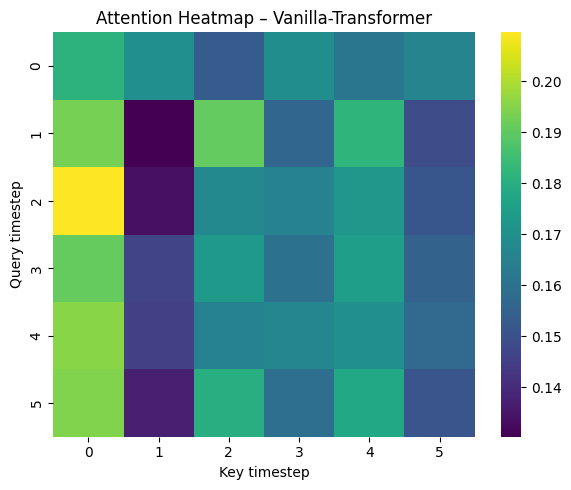

Generating attention heatmap for Conv-Attn-Transformer


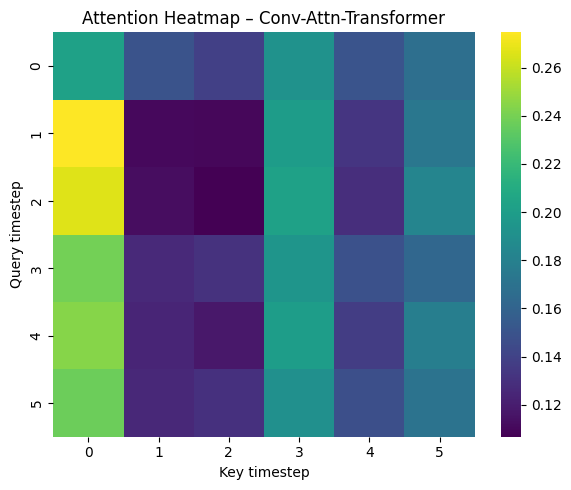

Generating attention heatmap for TFT-Simplified


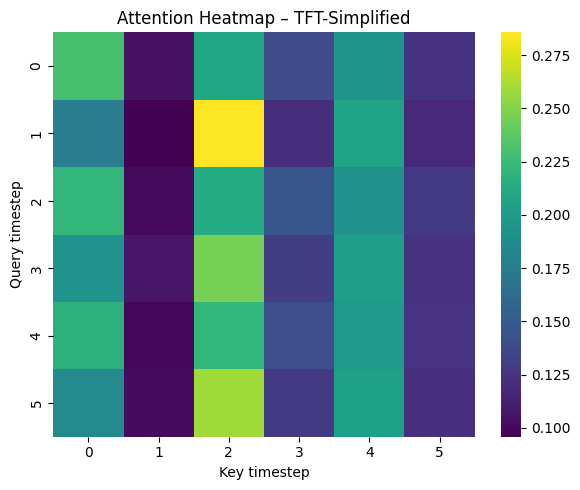

In [55]:
sample = X_test[:1]  # fixed shape (1, time, features)

for name, probe in attention_probes.items():
    print(f"Generating attention heatmap for {name}")

    attn_scores = probe.predict(sample, verbose=0)
    plot_attention_heatmap(attn_scores, name)


**recommendation function**

In [56]:
import numpy as np

def generate_recommendation(aqi_pred, day_prob, night_prob):
    alerts = []
    actions = []

    # AQI logic
    if aqi_pred > 300:
        alerts.append(f"CRITICAL: Hazardous Air Quality (AQI={aqi_pred:.0f})")
        actions.append("Avoid outdoor activity; wear N95 mask")
    elif aqi_pred > 200:
        alerts.append(f"WARNING: Very Unhealthy Air (AQI={aqi_pred:.0f})")
        actions.append("Close windows; limit outdoor exposure")

    # Day noise with confidence
    day_class = np.argmax(day_prob)
    day_conf = day_prob[day_class]

    if day_class == 2:
        alerts.append(
            f"ALERT: High Daytime Noise (confidence={day_conf:.2f})"
        )
        actions.append("Use noise-canceling headphones")

    # Night noise with confidence
    night_class = np.argmax(night_prob)
    night_conf = night_prob[night_class]

    if night_class == 2:
        alerts.append(
            f"ADVISORY: High Night Noise (confidence={night_conf:.2f})"
        )
        actions.append("Use earplugs or white noise")

    return {
        "alerts": alerts,
        "recommendations": actions
    }



**Test the recommender on real predictions**

In [57]:
vanilla_model = trained_models["Vanilla-Transformer"]

aqi_p, day_p, night_p = vanilla_model.predict(X_test[:1], verbose=0)

generate_recommendation(
    aqi_p[0][0],
    day_p[0],
    night_p[0]
)


{'alerts': ['ADVISORY: High Night Noise (confidence=0.75)'],
 'recommendations': ['Use earplugs or white noise']}

**Noise source**

In [58]:
def infer_noise_source(day_prob, night_prob, hour):
    if hour >= 7 and hour <= 22:
        if np.argmax(day_prob) == 2:
            return "Likely sources: Traffic, Construction, Public Activity"
    else:
        if np.argmax(night_prob) == 2:
            return "Likely sources: Traffic, Industrial Operations, Night Transport"
    return "No dominant noise source detected"


In [59]:
source = infer_noise_source(day_p[0], night_p[0], hour=21)


**RECOMMENDER VISUALS (DASHBOARD-STYLE)**

**Risk Score**

In [60]:
risk_score = (
    (results_df["AQI_R2"] < 0.9).astype(int) +
    (results_df["Night_F1_weighted"] < 0.75).astype(int)
)


**Calendar-style heatmap**

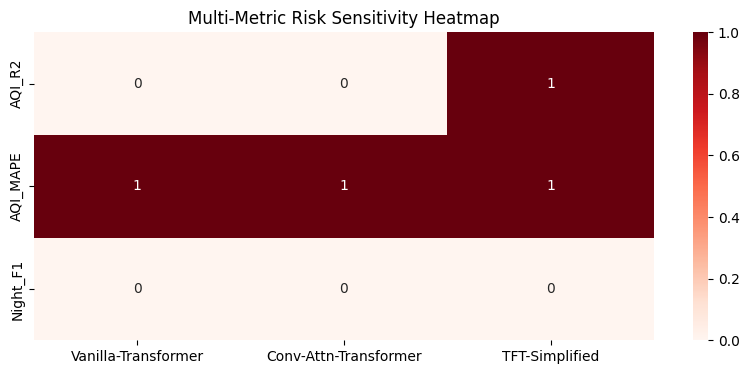

In [61]:
import seaborn as sns

risk_matrix = np.vstack([
    (results_df["AQI_R2"] < 0.9).astype(int),
    (results_df["AQI_MAPE"] > 8).astype(int),
    (results_df["Night_F1_weighted"] < 0.75).astype(int)
])

plt.figure(figsize=(10,4))
sns.heatmap(
    risk_matrix,
    cmap="Reds",
    annot=True,
    cbar=True,
    xticklabels=results_df["Model"],
    yticklabels=["AQI_R2", "AQI_MAPE", "Night_F1"]
)
plt.title("Multi-Metric Risk Sensitivity Heatmap")
plt.show()




**ERROR ANALYSIS BY AQI SEGMENT**

**Create AQI risk buckets**

In [62]:
import pandas as pd
import numpy as np

# AQI buckets based on CPCB / EPA style ranges
def aqi_bucket(aqi):
    if aqi <= 100:
        return "Low"
    elif aqi <= 200:
        return "Medium"
    else:
        return "High"


**Compute residuals + buckets**

In [63]:
vanilla_model = trained_models["Vanilla-Transformer"]

aqi_pred, day_p, night_p = vanilla_model.predict(X_test, verbose=0)
residuals = y_aqi_test - aqi_pred.flatten()

error_df = pd.DataFrame({
    "Actual_AQI": y_aqi_test,
    "Predicted_AQI": aqi_pred.flatten(),
    "Residual": residuals
})

error_df["AQI_Level"] = error_df["Actual_AQI"].apply(aqi_bucket)


**Box plot of residuals by AQI level**

/tmp/ipython-input-2389604793.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


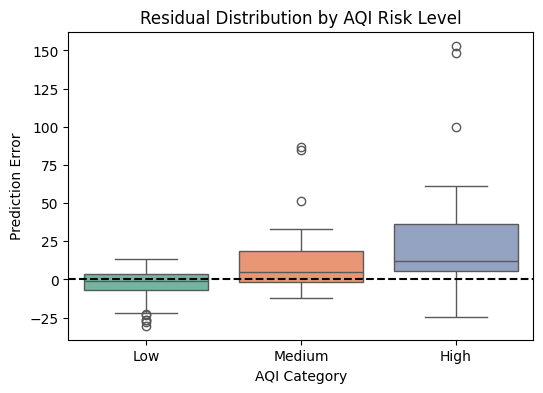

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(
    data=error_df,
    x="AQI_Level",
    y="Residual",
    palette="Set2"
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residual Distribution by AQI Risk Level")
plt.xlabel("AQI Category")
plt.ylabel("Prediction Error")
plt.show()


**FULL CALENDAR RISK HEATMAP**

**Create daily risk labels (AQI + Noise)**

In [65]:
n = len(y_aqi_test)

dates = pd.date_range(
    start="2026-01-01",
    periods=n,
    freq="D"
)


**Build the calendar dataframe**

In [66]:
calendar_df = pd.DataFrame({
    "Date": dates,
    "AQI": y_aqi_test,
    "Day_Noise": np.argmax(day_p, axis=1),
    "Night_Noise": np.argmax(night_p, axis=1)
})


**Compute daily risk**

In [67]:
def daily_risk(row):
    risk = 0
    if row["AQI"] > 200:
        risk += 1
    if row["Day_Noise"] == 2 or row["Night_Noise"] == 2:
        risk += 1
    return risk

calendar_df["Risk_Level"] = calendar_df.apply(daily_risk, axis=1)


**Build calendar heatmap**

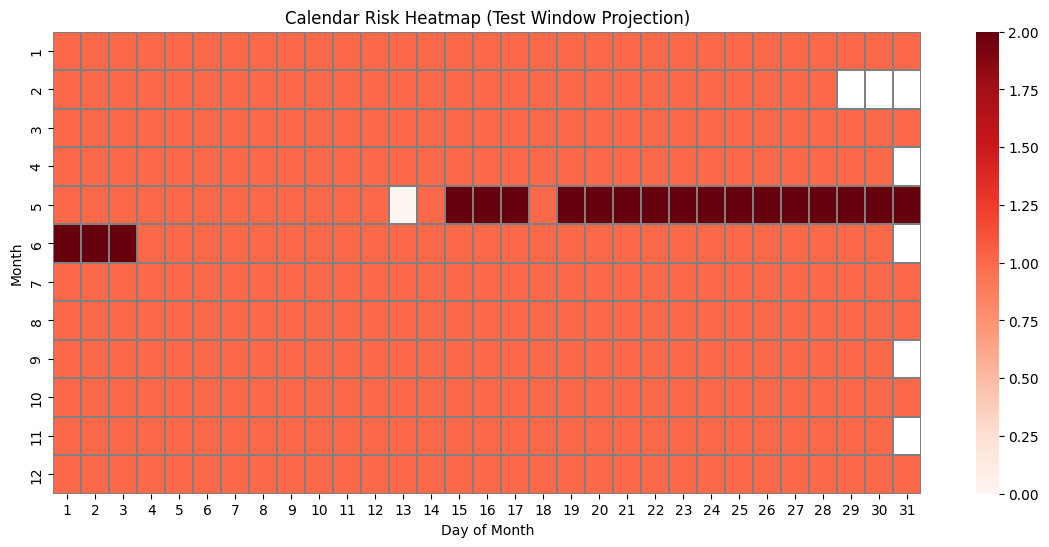

In [68]:
calendar_df["Day"] = calendar_df["Date"].dt.day
calendar_df["Month"] = calendar_df["Date"].dt.month

pivot = calendar_df.pivot_table(
    index="Month",
    columns="Day",
    values="Risk_Level",
    aggfunc="max"
)

plt.figure(figsize=(14,6))
sns.heatmap(
    pivot,
    cmap="Reds",
    linewidths=0.3,
    linecolor="gray",
    cbar=True
)
plt.title("Calendar Risk Heatmap (Test Window Projection)")
plt.xlabel("Day of Month")
plt.ylabel("Month")
plt.show()


In [69]:
calendar_df.head()
calendar_df.tail()
calendar_df["Risk_Level"].value_counts()


,count
Risk_Level,
1,423
2,19
0,1
